In [107]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import zarr
from pathlib import Path
from matplotlib.collections import LineCollection
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
from matplotlib.patches import Circle

POSSIBLE_ROOTS = [
    Path('/Volumes/data-1/Sasaki/MTsingleBeads'),
    Path('/Volumes/data-1/sasaki/MTsingleBeads'),
    Path('/Volumes/data/Sasaki/MTsingleBeads'),
    Path('/Volumes/data/sasaki/MTsingleBeads'),
    Path('/Volumes/data/Sasaki/MTSingleBeads'),
]



input_dir = POSSIBLE_ROOTS[2]/'beads5um/20260715/beads5um003'

output_dir = POSSIBLE_ROOTS[2] / "figure/exp_snap"

MTs = zarr.open(input_dir / 'GFP.zarr', mode='r')
beads = zarr.open(input_dir / 'beads.zarr', mode='r')

df = pd.read_csv(input_dir /'beads_tracks.csv')


bead_diameter_um = 1.18  # ビーズの直径 [μm]
pixel_size_um = 0.11  # 空間解像度 [μm/px]
bead_radius_px = (bead_diameter_um / pixel_size_um / 2)

In [113]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors

gfp_base = mcolors.to_rgb("#00A960")  # (0.0, 0.663, 0.376)

cud_gfp_cmap = mcolors.LinearSegmentedColormap.from_list(
    "cud_gfp",
    [
        (0.0, (0.0, 0.0, 0.0, 1.0)),              # 輝度0: 完全透明な黒
        (0.7, (gfp_base[0], gfp_base[1], gfp_base[2], 1.0)), # 輝度70%: 純粋なCUD緑（半透明）
        (1.0, (0.6, 1.0, 0.75, 1.0))              # 輝度100%: 芯が光るエメラルドホワイト（不透明）
    ]
)

beads_base = mcolors.to_rgb("#E4007F")  # (0.894, 0.0, 0.498)

cud_magenta_cmap = mcolors.LinearSegmentedColormap.from_list(
    "cud_magenta",
    [
        (0.0, (0.0, 0.0, 0.0, 0.0)),                  # 輝度0: 完全透明な黒
        (0.7, (beads_base[0], beads_base[1], beads_base[2], 0.7)), # 輝度70%: 純粋なCUDマゼンタ（半透明）
        (1.0, (1.0, 0.65, 0.85, 1.0))                  # 輝度100%: 芯が光るパステルマゼンタホワイト（不透明）
    ]
)
MTs_max_factor = 0.15
beads_max_factor = 0.7

# カラーマップ (plasma) とフレームの正規化範囲を設定
cmap = plt.get_cmap("plasma")
norm = plt.Normalize(vmin=df["frame"].min(), vmax=df["frame"].max())

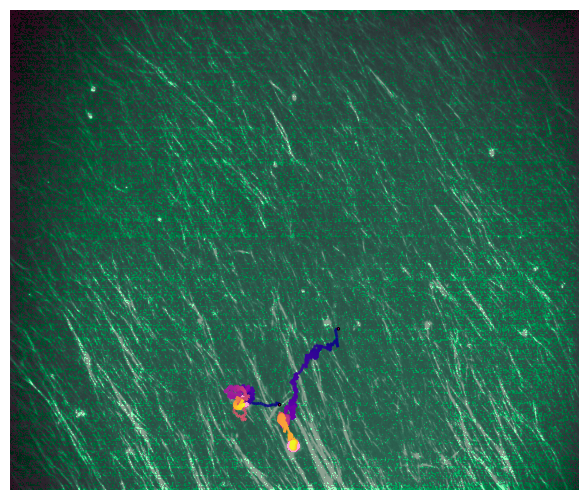

In [114]:
# 図を2つ並べて表示する場合
fig, ax = plt.subplots()
# 最初のプロット：MTs
ax.imshow(MTs[-1], cmap=cud_gfp_cmap, vmin=MTs[-1].min(), vmax = MTs[-1].max()*MTs_max_factor)

# 2番目のプロット：beads（マスク付き）
ax.imshow(beads[-1], cmap=cud_magenta_cmap, interpolation="nearest", vmin=beads[-1].min(), vmax = beads[-1].max()*beads_max_factor)

# 各粒子（particle）ごとに軌跡を線分に分解して描画
for particle_id, group in df.groupby("particle"):
    group = group.sort_values("frame")

    # (N, 2) の座標列を (N-1, 2, 2) の線分配列に変換
    points = np.array([group["x"], group["y"]]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # 各線分の始点フレーム番号を色として割り当て
    frames = group["frame"].values[:-1]

    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2, alpha=0.9)
    lc.set_array(frames)
    ax.add_collection(lc)

    # 始点マーカー（実寸大の Circle パッチ）
    start_x = group["x"].iloc[0]
    start_y = group["y"].iloc[0]
    start_color = cmap(norm(group["frame"].iloc[0]))

    circle = Circle(
      xy=(start_x, start_y),
      radius=bead_radius_px,
      facecolor="#E4007F",
      edgecolor="black",
      linewidth=0.8,
      zorder=5,
    )
    ax.add_patch(circle)

ax.axis('off')
ax.set_position([0, 0, 1, 1]) # AxesをFigure全体に限界まで広げる
fig.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0)

fontprops = fm.FontProperties(size=24)
size_bar = AnchoredSizeBar(ax.transData,
                           size=50/0.11,
                           label='',
                           loc=3,
                           pad=0.5,
                           color='white',
                           frameon=False,
                           size_vertical=20,
                           fontproperties=fontprops)
#ax.add_artist(size_bar)


In [115]:
fig.savefig(output_dir / "beads5um003.pdf", bbox_inches="tight")